<a href="https://colab.research.google.com/github/ishikaagarwal055/Data-Science/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preprocessing**

In [ ]:
import pandas as pd

data = {
    'Name' :['Ram','Kamal','ajay'],
    'Age' : [25,None,32],
    'Salary' : [5000,6000,None]
}
df = pd.DataFrame(data)
print("Original Dataframe")
print(df)
print()
print("Data representing number of null values")
print(df.isna().sum())
print()

# null findout | fillna | dropna

print("Data without null values")

df['Age']= df['Age'].fillna(df['Age'].mean())

df['Salary'].fillna(df['Salary'].mean(),inplace=True)
print(df)

print("\nMissing values after preprocessing\n")
print(df.isnull().sum())


Original Dataframe
    Name   Age  Salary
0    Ram  25.0  5000.0
1  Kamal   NaN  6000.0
2   ajay  32.0     NaN

Data representing number of null values
Name      0
Age       1
Salary    1
dtype: int64

Data without null values
    Name   Age  Salary
0    Ram  25.0  5000.0
1  Kamal  28.5  6000.0
2   ajay  32.0  5500.0

Missing values after preprocessing

Name      0
Age       0
Salary    0
dtype: int64


/tmp/ipykernel_610/3258864331.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].mean(),inplace=True)


In [ ]:
# Encoding
from sklearn.preprocessing import LabelEncoder
import pandas as pd

data = {
    'Name' :['Ram','Kamal','Ajay','Neetu','Kavi','Sapu'],
    'Age' : [25,None,32,20,21,22],
    'Salary' : [5000,6000,None,7000,8000,9000],
    'Gender' : ['Male','Male','Male',None,'Female','Female']
}
df = pd.DataFrame(data)
print("Original dataframe")
print(df)

# label encoder
le = LabelEncoder()
df_label = df.copy()
df_label['Gender'] = df['Gender'].fillna('unknown')
df_label['Gender_encoder'] = le.fit_transform(df_label['Gender'])
print("\nDataframe after label encoding")
print(df_label)

Original dataframe
    Name   Age  Salary  Gender
0    Ram  25.0  5000.0    Male
1  Kamal   NaN  6000.0    Male
2   Ajay  32.0     NaN    Male
3  Neetu  20.0  7000.0    None
4   Kavi  21.0  8000.0  Female
5   Sapu  22.0  9000.0  Female

Dataframe after label encoding
    Name   Age  Salary   Gender  Gender_encoder
0    Ram  25.0  5000.0     Male               1
1  Kamal   NaN  6000.0     Male               1
2   Ajay  32.0     NaN     Male               1
3  Neetu  20.0  7000.0  unknown               2
4   Kavi  21.0  8000.0   Female               0
5   Sapu  22.0  9000.0   Female               0


In [ ]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
data = {
    'colors' : ['red','blue','green','red','blue']
}
df = pd.DataFrame(data)
print("Original data")
print(df)
# one hot encoding
encoded_df = pd.get_dummies(df,columns=['colors'])
print("\nDataframe after one hot encoding")
print(encoded_df)

Original data
  colors
0    red
1   blue
2  green
3    red
4   blue

Dataframe after one hot encoding
   colors_blue  colors_green  colors_red
0        False         False        True
1         True         False       False
2        False          True       False
3        False         False        True
4         True         False       False


In [ ]:
import pandas as pd
import numpy as np
data = {
    'colors': ['red', 'blue', 'green', 'red', 'blue','orange',np.nan],
}
df = pd.DataFrame(data)
print(df)

# handle null values
df.dropna(inplace=True)
print(df)

   colors
0     red
1    blue
2   green
3     red
4    blue
5  orange
6     NaN
   colors
0     red
1    blue
2   green
3     red
4    blue
5  orange


In [ ]:
# label encoding
from sklearn.preprocessing import LabelEncoder

# method 1
le = LabelEncoder()
df['colors_encoder1'] = le.fit_transform(df['colors'])

# method 2
df['colors_encoder2'] = LabelEncoder().fit_transform(df['colors'])
# print(df)

# method 3
import sklearn
df['colors_encoder3'] = sklearn.preprocessing.LabelEncoder().fit_transform(df['colors'])
print(df)






   colors  colors_encoder1  colors_encoder2  colors_encoder3
0     red                3                3                3
1    blue                0                0                0
2   green                1                1                1
3     red                3                3                3
4    blue                0                0                0
5  orange                2                2                2


In [ ]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder

# drop cols of label encoding
if 'colors_encoder' in df.keys():
  df.drop(df[['colors_encoder','colors_encoder1','colors_encoder2','colors_encoder3']],axis=1,inplace = True)

print(df)

# one hot encoding (by the help of pandas)
df_encoder = pd.get_dummies(df,columns=['colors'])
print(df_encoder)

   colors  colors_encoder1  colors_encoder2  colors_encoder3
0     red                3                3                3
1    blue                0                0                0
2   green                1                1                1
3     red                3                3                3
4    blue                0                0                0
5  orange                2                2                2
   colors_encoder1  colors_encoder2  colors_encoder3  colors_blue  \
0                3                3                3        False   
1                0                0                0         True   
2                1                1                1        False   
3                3                3                3        False   
4                0                0                0         True   
5                2                2                2        False   

   colors_green  colors_orange  colors_red  
0         False          False        True  

In [ ]:
# combination of handling missing values | label encoding | onehot encoding
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

data = {
    "age" : [10,20,np.nan,26,30],
    "gender" : ["male","female","others","male",None],
    "name" : ['dheeraj','kavi','sapu','yash','hello']

}

df = pd.DataFrame(data)

# handle missing values
df['age'] = df['age'].fillna(df['age'].mean())
df['gender'] = df['gender'].dropna()
print(df)

# label encoding
le = LabelEncoder()
df['gender1'] = le.fit_transform(df['gender'])
print(df)

# one hot encoding
oe = OneHotEncoder()
oe_e = oe.fit_transform(df[['gender']]).toarray()
print(oe_e)

    age  gender     name
0  10.0    male  dheeraj
1  20.0  female     kavi
2  21.5  others     sapu
3  26.0    male     yash
4  30.0     NaN    hello
    age  gender     name  gender1
0  10.0    male  dheeraj        1
1  20.0  female     kavi        0
2  21.5  others     sapu        2
3  26.0    male     yash        1
4  30.0     NaN    hello        3
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


In [ ]:
# feature scaling
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = {
    'experience' : [300,600,900,1500],
    'salary': [1000,1500,2000,3000]
}

# data frame
df = pd.DataFrame(data)
print(df)

# feature scale experience ko kiya h
scalar = StandardScaler()
df['experience'] = scalar.fit_transform(df[['experience']]) # 2d
print(df)

# split data
x = df['experience']
y = df['salary']

print(x)
print(y)

   experience  salary
0         300    1000
1         600    1500
2         900    2000
3        1500    3000
   experience  salary
0   -1.183216    1000
1   -0.507093    1500
2    0.169031    2000
3    1.521278    3000
0   -1.183216
1   -0.507093
2    0.169031
3    1.521278
Name: experience, dtype: float64
0    1000
1    1500
2    2000
3    3000
Name: salary, dtype: int64


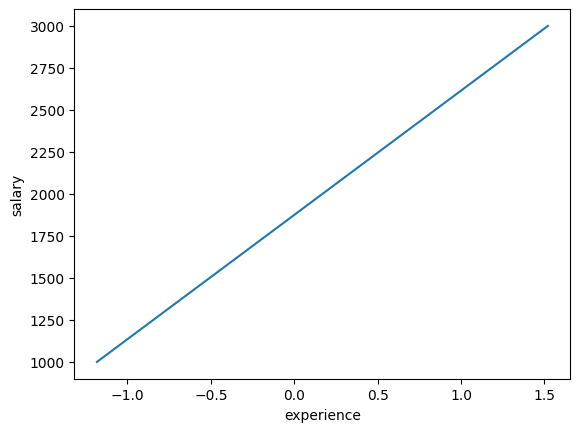

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(x,y)
plt.xlabel('experience')
plt.ylabel('salary')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = {
    'experience' : [300,600,900,1500],
    'salary': [1000,1500,2000,3000]
}

# data frame
df = pd.DataFrame(data)
print(df)

#split data
x = df['experience']
y = df['salary']

# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("x train",x_train)
print()
print("x test",x_test)
print("y train",y_train)
print("y test",y_test)

   experience  salary
0         300    1000
1         600    1500
2         900    2000
3        1500    3000
x train 3    1500
0     300
2     900
Name: experience, dtype: int64

x test 1    600
Name: experience, dtype: int64
y train 3    3000
0    1000
2    2000
Name: salary, dtype: int64
y test 1    1500
Name: salary, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/rajendra0968jangid/Ds-Arya/main/extended_salary_data.csv"
df = pd.read_csv(url)
print(df)

# data frame
# df = pd.DataFrame(data)
# print(df)

#split data
x = df[['experience']]
y = df['salary']

# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("x train",x_train)
print()
print("x test",x_test)
print("y train",y_train)
print("y test",y_test)

     experience  salary
0           300    1000
1           600    1500
2           900    2000
3          1500    3000
4          1800    3500
..          ...     ...
99        30300   51000
100       30600   51500
101       30900   52000
102       31200   52500
103       31500   53000

[104 rows x 2 columns]
x train      experience
55        17100
22         7200
76        23400
44        13800
72        22200
..          ...
71        21900
14         4800
92        28200
51        15900
102       31200

[83 rows x 1 columns]

x test     experience
30        9600
65       20100
64       19800
53       16500
45       14100
93       28500
91       27900
47       14700
10        3600
0          300
18        6000
31        9900
88       27000
95       29100
77       23700
4         1800
80       24600
33       10500
12        4200
26        8400
98       30000
y train 55     29000
22     12500
76     39500
44     23500
72     37500
       ...  
71     37000
14      8500
92     47500
51

In [ ]:
# simple linear regression
from sklearn.linear_model import LinearRegression

# model fit
model = LinearRegression()
model.fit(x_train,y_train)   # 2d

# input from user
user = int(input("enter your experience"))

# model prediction
new_data = {
    'experience': [user]

}

df1 = pd.DataFrame(new_data)
print(df1)
pred_data = model.predict(df1)
print(pred_data[0])


enter your experience20
   experience
0          20
533.3333333333478


# **Project using mysql and joblib and SLR MLR**

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data={
    'name': ['ishika', 'sakshi', 'ishuu', 'iqraa'],
    'avg_income': [1000,200,300,400],
    'house_age': [10.2,2.5,3.0,4.0],
    'num_rooms': [3,4,5,1],
    'price': [10000, 7000, 15000, 11000]
}

df = pd.DataFrame(data)

# handle missing values
df.drop("name",axis=1, inplace = True)

# feature scaling
scaler = StandardScaler()
df[['avg_income','house_age','num_rooms']] = scaler.fit_transform(df[['avg_income','house_age','num_rooms']])
print(df)

# split data
x = df[['avg_income','house_age','num_rooms']]
y = df['price']

# train test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=22)

# model train
model = LinearRegression()
model.fit(x_train,y_train)

# prediction data
new_data = pd.DataFrame({
    'avg_income': [900],
    'house_age': [8],
    'num_rooms': [5]
})

# feature scaling
new_data[['avg_income','house_age','num_rooms']] = scaler.fit_transform(new_data[['avg_income','house_age','num_rooms']])

# prediction
predict_data = model.predict(new_data)
print(predict_data[0])

# model dump
# !pip install joblib
import joblib
joblib.dump(model,'house_model.joblib')


   avg_income  house_age  num_rooms  price
0    1.686761   1.705444  -0.169031  10000
1   -0.883541  -0.784019   0.507093   7000
2   -0.562254  -0.622366   1.183216  15000
3   -0.240966  -0.299059  -1.521278  11000
5176.27452680298


['house_model.joblib']

sql k liye

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# mysql connector
# !pip install mysql.connector
# !pip install pymysql cryptography
import pymysql
conn = pymysql.connect(host='13.220.156.88',user='mluser',database='ml_db',password='mlpass123')
print(conn)
query = 'select * from houses'

df = pd.read_sql(query,conn)
print(df)

# data={
#     'name': ['ishika', 'sakshi', 'ishuu', 'iqraa'],
#     'avg_income': [1000,200,300,400],
#     'house_age': [10.2,2.5,3.0,4.0],
#     'num_rooms': [3,4,5,1],
#     'price': [10000, 7000, 15000, 11000]
# }

# df = pd.DataFrame(data)

# handle missing values
df.drop("name",axis=1, inplace = True)

# feature scaling
scaler = StandardScaler()
# df[['avg_income','house_age','num_rooms']] = scaler.fit_transform(df[['avg_income','house_age','num_rooms']])
print(df)

# split data
x = df[['avg_income','house_age','num_rooms']]
y = df['price']

# train test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=22)

# model train
model = LinearRegression()
model.fit(x_train,y_train)

# prediction data
new_data = pd.DataFrame({
    'avg_income': [900],
    'house_age': [8],
    'num_rooms': [5]
})

# feature scaling
new_data[['avg_income','house_age','num_rooms']] = scaler.fit_transform(new_data[['avg_income','house_age','num_rooms']])

# prediction
predict_data = model.predict(new_data)
print(predict_data[0])

# model dump
# !pip install joblib
import joblib
joblib.dump(model,'house_model.joblib')


   id     name  avg_income  house_age  num_rooms    price
0   1  praveen        1000       10.2          3  10000.0
1   2  dheeraj         200        2.5          4   7000.0
2   3     yash         300        3.0          5  15000.0
3   4    kunal         400        4.0          1  11000.0
   id  avg_income  house_age  num_rooms    price
0   1        1000       10.2          3  10000.0
1   2         200        2.5          4   7000.0
2   3         300        3.0          5  15000.0
3   4         400        4.0          1  11000.0
-17020.99652359676


/tmp/ipykernel_1607/1023524310.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


['house_model.joblib']